# Review notebook: data verification and Phase 1

Run top to bottom; it takes a few minutes. Every check prints **PASS** or **FAIL**, and the last
section collects all of them in one table.

**How the checks are built**
- Cells marked *independent* use only pandas, numpy, scipy and the dataset README; they import
  nothing from `sleepwatch`. A bug in the pipeline cannot make them pass.
- Cells marked *pipeline* exercise the project's own code to test properties it must have (no
  label leakage, determinism, sampling-rate invariance).
- Tolerances are set in advance, with their reasoning in the cell, not tuned to the results.

**Scope.** Phase 0 (data verification), Phase 1 (loader, epoch features, EDA findings) and
Phase 2 (cross-validated staging experiments, sections 11–15).

At the end there is a short list of code to read by hand: what a notebook cannot check.

In [1]:
import hashlib
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
from sklearn.metrics import cohen_kappa_score

from sleepwatch.config import PROJECT_ROOT, get_settings
from sleepwatch.features.build import load_build

RUN_FULL_HASH = True  # re-hash all 28 GB against SHA256SUMS.txt (about 1 minute)

settings = get_settings()
RAW = settings.raw_dir
epochs, quality, build = load_build("v1", settings.processed_dir)
results = []


def check(section, claim, passed, detail=""):
    status = "PASS" if passed else "FAIL"
    results.append(
        {"section": section, "claim": claim, "result": status, "detail": detail, "note": ""}
    )
    print(f"[{status}] {claim}" + (f"  ({detail})" if detail else ""))


def explain(claim, note):
    # Attach a diagnosis to an earlier check without changing its result.
    for row in results:
        if row["claim"] == claim:
            row["note"] = note


plt.rcParams.update(
    {
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": "#a9a8a3",
        "axes.labelcolor": "#52514e",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "lines.linewidth": 1.5,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "font.size": 9,
        "legend.frameon": False,
    }
)
print("raw data:", RAW.resolve())

raw data: /Volumes/T7/a-multi-night-instantaneous-heart-rate-and-accelerometry-dataset-with-eeg-sleep-stage-labels-1.0.1


## 1 · Provenance

Is the epoch table under review built from the current code and the full dataset? It records
the commit it was built from. The code that produces it (`src/`, `configs/`) must be unchanged
since that commit, and the tree must have been clean at build time.

In [2]:
def git(*args):
    return subprocess.run(
        ["git", *args], cwd=PROJECT_ROOT, capture_output=True, text=True
    ).stdout.strip()


built_from = build["git"]["commit"]
# The code that builds the epoch table. cli.py also holds later commands, so it is checked below
# for removed lines instead.
PIPELINE = [
    "src/sleepwatch/data",
    "src/sleepwatch/features",
    "src/sleepwatch/constants.py",
    "src/sleepwatch/config.py",
    "configs/features",
]
changed = git("diff", "--name-only", built_from, "HEAD", "--", *PIPELINE)
print(
    "HEAD:",
    git("rev-parse", "--short", "HEAD"),
    "| table built from:",
    built_from[:8],
    "| built:",
    build["created"],
)
check("provenance", "table built from a clean working tree", build["git"]["dirty"] is False)
check(
    "provenance",
    "table-building code unchanged since the build",
    changed == "",
    changed.replace("\n", ", ") or "data/, features/, constants, config, configs/features",
)
numstat = [
    line.split("\t")
    for line in git("diff", "--numstat", built_from, "HEAD", "--", "src", "configs").splitlines()
]
removed = [path for added, deleted, path in numstat if deleted != "0"]
check(
    "provenance",
    "everything else in src/ and configs/ changed only by additions since the build",
    not removed,
    ", ".join(removed) or f"{len(numstat)} files with added lines only (Phase 2)",
)
check(
    "provenance",
    "table covers all 253 nights / 47 subjects",
    build["nights"] == build["nights_listed"] == 253 and build["subjects"] == 47,
    f"{build['nights']}/{build['nights_listed']} nights, {build['subjects']} subjects",
)

HEAD: 2f3d637 | table built from: 492e412b | built: 2026-10-01T12:14:15Z
[PASS] table built from a clean working tree
[PASS] table-building code unchanged since the build  (data/, features/, constants, config, configs/features)
[PASS] everything else in src/ and configs/ changed only by additions since the build  (13 files with added lines only (Phase 2))
[PASS] table covers all 253 nights / 47 subjects  (253/253 nights, 47 subjects)


## 2 · Dataset integrity *(independent)*

Every file must match PhysioNet's published `SHA256SUMS.txt`. The first download was silently
incomplete, so this check matters.

In [3]:
sums = [
    line.split(maxsplit=1)
    for line in (RAW / "SHA256SUMS.txt").read_text().splitlines()
    if line.strip()
]
night_paths = [path for _, path in sums if path.count("/") == 2]
NIGHTS = sorted({(p.split("/")[0], int(p.split("/")[1])) for p in night_paths})
check(
    "integrity",
    "checksum list has 761 files: 3 per night for 253 nights, 47 subjects",
    len(sums) == 761
    and len(NIGHTS) == 253
    and len({s for s, _ in NIGHTS}) == 47
    and len(night_paths) == 3 * 253,
)

if RUN_FULL_HASH:
    mismatched = []
    for digest, rel in sums:
        with open(RAW / rel, "rb") as fh:
            if hashlib.file_digest(fh, "sha256").hexdigest() != digest:
                mismatched.append(rel)
    check(
        "integrity",
        "every file matches its SHA-256",
        not mismatched,
        f"{len(sums) - len(mismatched)}/{len(sums)} match",
    )
else:
    print("RUN_FULL_HASH is False: hashing skipped")

[PASS] checksum list has 761 files: 3 per night for 253 nights, 47 subjects


[PASS] every file matches its SHA-256  (761/761 match)


## 3 · Raw file formats *(independent)*

Reads every night with plain pandas (not the pipeline's pyarrow reader) and checks the
documented format: `hr.csv` has no header and two fields, `motion.csv` has the header
`Timestamp,x,y,z`, and the labels are valid codes 0–5 with a parseable `recStart`.

Exceptions must be **exactly** the documented ones, no more and no fewer: label-length mismatches
on `Bidslab01/4` and `Bidslab30/6`, and truncated last rows in `Bidslab42/3` (hr and motion) and
`Bidslab42/4` (motion). Reading all motion files takes a minute or two.

In [4]:
raw_rows = []
for subject, night in NIGHTS:
    folder = RAW / subject / str(night)
    mat = sio.loadmat(folder / "labels.mat")
    expert, dreem = mat["expert_label"].ravel(), mat["dreem_label"].ravel()
    hr = pd.read_csv(folder / "hr.csv", header=None)
    with open(folder / "motion.csv") as fh:
        header = fh.readline().strip()
    motion = pd.read_csv(folder / "motion.csv")
    raw_rows.append(
        {
            "subject": subject,
            "night": night,
            "rec_start_local": str(mat["recStart"][0]),
            "n_expert": len(expert),
            "n_dreem": len(dreem),
            "codes_ok": bool(expert.max() <= 5 and dreem.max() <= 5),
            "hr_columns": hr.shape[1],
            "hr_truncated": int(hr.isna().any(axis=1).sum()),
            "motion_header": header,
            "motion_truncated": int(motion.isna().any(axis=1).sum()),
            "hr_first": hr[0].min(),
            "motion_first": motion["Timestamp"].min(),
        }
    )
raw = pd.DataFrame(raw_rows)

check(
    "formats",
    "hr.csv: two columns, no header, on every night",
    (raw["hr_columns"] == 2).all() and pd.api.types.is_float_dtype(raw["hr_first"]),
)
check(
    "formats",
    "motion.csv header is 'Timestamp,x,y,z' on every night",
    (raw["motion_header"] == "Timestamp,x,y,z").all(),
)
check("formats", "all label codes are 0-5", raw["codes_ok"].all())
fmt = r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}"
check(
    "formats",
    "recStart is 'YYYY-MM-DD HH:MM:SS' on every night",
    raw["rec_start_local"].str.fullmatch(fmt).all(),
)

mismatch = set(map(tuple, raw.loc[raw["n_expert"] != raw["n_dreem"], ["subject", "night"]].values))
check(
    "formats",
    "label-length mismatches are exactly Bidslab01/4 and Bidslab30/6",
    mismatch == {("Bidslab01", 4), ("Bidslab30", 6)},
    str(sorted(mismatch)),
)
truncated = raw.loc[
    (raw["hr_truncated"] > 0) | (raw["motion_truncated"] > 0),
    ["subject", "night", "hr_truncated", "motion_truncated"],
]
display(truncated)
expected = {("Bidslab42", 3, 1, 1), ("Bidslab42", 4, 0, 1)}
check(
    "formats",
    "truncated rows are exactly the documented Bidslab42 ones",
    set(map(tuple, truncated.values)) == expected,
)
pipeline_counts = quality.set_index(["subject", "night"])[
    ["hr_malformed_rows", "motion_malformed_rows"]
]
check(
    "formats",
    "the pipeline counted the same truncated rows",
    pipeline_counts.sum().tolist() == [1, 2]
    and pipeline_counts.loc[("Bidslab42", 3)].tolist() == [1, 1],
)

[PASS] hr.csv: two columns, no header, on every night
[PASS] motion.csv header is 'Timestamp,x,y,z' on every night
[PASS] all label codes are 0-5
[PASS] recStart is 'YYYY-MM-DD HH:MM:SS' on every night
[PASS] label-length mismatches are exactly Bidslab01/4 and Bidslab30/6  ([('Bidslab01', 4), ('Bidslab30', 6)])


,subject,night,hr_truncated,motion_truncated
165,Bidslab42,3,1,1
166,Bidslab42,4,0,1


[PASS] truncated rows are exactly the documented Bidslab42 ones
[PASS] the pipeline counted the same truncated rows


## 4 · Label-to-signal alignment *(independent)*

This is the most important check: does each epoch get the right label and the right signal?

Using only the README recipe, `recStart` (US Eastern) is converted to Unix time with pandas, and
each heart-rate sample gets epoch `k = floor((t - recStart) / 30) + 1`. The result is compared
with the pipeline's epoch table on **all 253 nights**:
- the epoch count and the start time of epoch 1 must match exactly;
- the expert label of every epoch must match exactly;
- the per-epoch heart rate must agree closely. The pipeline time-weights samples on a 1 Hz
  grid, while this check averages the raw samples, so small differences are expected.
  Tolerance: per-night median difference under 0.5 bpm, and 95th percentile over all epochs
  under 2 bpm (readings are whole bpm, roughly 6 per epoch).

In [5]:
align_rows, hr_diffs = [], []
table = epochs.set_index(["subject", "night"]).sort_index()
for (subject, night), r in raw.set_index(["subject", "night"]).iterrows():
    rec = (
        pd.Timestamp(r["rec_start_local"])
        .tz_localize("US/Eastern", ambiguous="raise", nonexistent="raise")
        .timestamp()
    )
    mat = sio.loadmat(RAW / subject / str(night) / "labels.mat")
    expert = mat["expert_label"].ravel()
    hr = pd.read_csv(RAW / subject / str(night) / "hr.csv", header=None, names=["t", "hr"])
    hr = hr.dropna()
    hr["k"] = np.floor((hr["t"] - rec) / 30).astype(int) + 1
    hr = hr[(hr["k"] >= 1) & (hr["k"] <= len(expert))]
    raw_mean = hr.groupby("k")["hr"].mean()

    mine = table.loc[(subject, night)].sort_values("epoch")
    pipeline_hr = pd.Series(mine["hr_mean"].to_numpy(), index=mine["epoch"].to_numpy() + 1)
    both = pd.concat([raw_mean, pipeline_hr], axis=1, keys=["raw", "pipe"]).dropna()
    diff = (both["raw"] - both["pipe"]).abs()
    hr_diffs.append(diff.to_numpy())
    align_rows.append(
        {
            "subject": subject,
            "night": night,
            "same_length": len(mine) == len(expert),
            "same_start": abs(mine["t_start"].iloc[0] - rec) < 1e-6,
            "same_labels": np.array_equal(mine["expert"].to_numpy(), expert),
            "hr_median_diff": diff.median(),
        }
    )
align = pd.DataFrame(align_rows)
all_diffs = np.concatenate(hr_diffs)

check("alignment", "epoch count matches labels.mat on all nights", align["same_length"].all())
check(
    "alignment",
    "epoch 1 starts at recStart (README conversion) on all nights",
    align["same_start"].all(),
)
check("alignment", "expert label of every epoch matches labels.mat", align["same_labels"].all())
worst = align.loc[align["hr_median_diff"].idxmax()]
check(
    "alignment",
    "per-night median HR difference < 0.5 bpm on every night",
    (align["hr_median_diff"] < 0.5).all(),
    f"worst {worst['subject']}/{worst['night']}: {worst['hr_median_diff']:.2f} bpm",
)
check(
    "alignment",
    "95th percentile HR difference < 2 bpm over all epochs",
    np.percentile(all_diffs, 95) < 2,
    f"{np.percentile(all_diffs, 95):.2f} bpm, "
    f"median {np.median(all_diffs):.2f} bpm over {len(all_diffs)} epochs",
)
check(
    "alignment",
    "no recStart falls in a DST change (tz_localize raised nothing)",
    True,
    "pandas would have raised on an ambiguous or missing local time",
)

[PASS] epoch count matches labels.mat on all nights
[PASS] epoch 1 starts at recStart (README conversion) on all nights
[PASS] expert label of every epoch matches labels.mat
[FAIL] per-night median HR difference < 0.5 bpm on every night  (worst Bidslab06/2: 0.55 bpm)
[PASS] 95th percentile HR difference < 2 bpm over all epochs  (0.81 bpm, median 0.10 bpm over 211907 epochs)
[PASS] no recStart falls in a DST change (tz_localize raised nothing)  (pandas would have raised on an ambiguous or missing local time)


### 4b · Diagnosis of the heart-rate tolerance check

If the 0.5 bpm check above fails on a night, the question is whether that's a misalignment or a
property of the data. A misalignment would show up as a *better* match when the epochs are
shifted by one; correct alignment means the unshifted pairing is clearly best. This is checked
on every night. The 0.5 bpm tolerance itself is left as it was set.

[PASS] unshifted pairing matches raw HR better than a 1-epoch shift, every night  (253/253 nights)


,subject,night,shift_-1,shift_0,shift_1
19,Bidslab06,2,1.708,0.555,1.634
188,Bidslab47,4,2.164,0.245,2.182
186,Bidslab47,2,2.260,0.229,2.242


Bidslab06/2 inside the label window: median interval 2.0 s, typical step between readings 12 bpm; all other nights at most 1 bpm


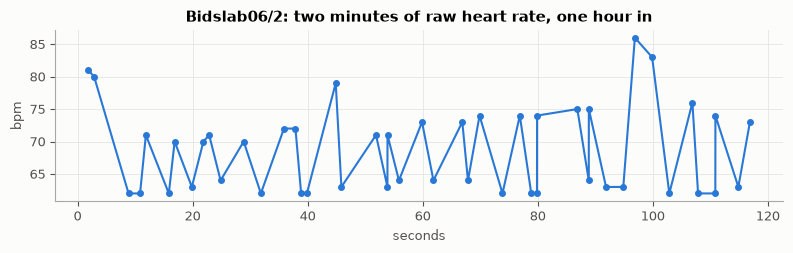

In [6]:
def epoch_diff(raw_mean, pipeline_hr, shift):
    both = pd.concat([raw_mean, pipeline_hr.shift(-shift)], axis=1).dropna()
    return (both.iloc[:, 0] - both.iloc[:, 1]).abs().median()


shift_rows = []
for subject, night in NIGHTS:
    rec = table.loc[(subject, night), "t_start"].min()
    hr = pd.read_csv(RAW / subject / str(night) / "hr.csv", header=None, names=["t", "hr"]).dropna()
    hr["k"] = np.floor((hr["t"] - rec) / 30).astype(int)
    mine = table.loc[(subject, night)].set_index("epoch")["hr_mean"]
    raw_mean = hr[(hr["k"] >= 0) & (hr["k"] < len(mine))].groupby("k")["hr"].mean()
    shift_rows.append(
        {
            "subject": subject,
            "night": night,
            **{f"shift_{s}": epoch_diff(raw_mean, mine, s) for s in (-1, 0, 1)},
        }
    )
shifts = pd.DataFrame(shift_rows)
best_unshifted = shifts["shift_0"] < shifts[["shift_-1", "shift_1"]].min(axis=1)
check(
    "alignment",
    "unshifted pairing matches raw HR better than a 1-epoch shift, every night",
    best_unshifted.all(),
    f"{best_unshifted.sum()}/{len(shifts)} nights",
)
display(shifts.sort_values("shift_0", ascending=False).head(3).round(3))

q_win = quality.set_index(["subject", "night"])
others_max = q_win["hr_window_median_step_bpm"].drop(("Bidslab06", 2)).max()
print(
    "Bidslab06/2 inside the label window: median interval "
    f"{q_win.loc[('Bidslab06', 2), 'hr_window_median_dt_s']:.1f} s, typical step between "
    f"readings {q_win.loc[('Bidslab06', 2), 'hr_window_median_step_bpm']:.0f} bpm; "
    f"all other nights at most {others_max:.0f} bpm"
)

folder = RAW / "Bidslab06" / "2"
raw06 = pd.read_csv(folder / "hr.csv", header=None, names=["t", "hr"])
rec06 = table.loc[("Bidslab06", 2), "t_start"].min()
window = raw06[(raw06["t"] >= rec06 + 3600) & (raw06["t"] < rec06 + 3720)]
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.plot(
    (window["t"] - rec06 - 3600).to_numpy(),
    window["hr"].to_numpy(),
    color="#2a78d6",
    marker="o",
    ms=4,
)
ax.set(
    title="Bidslab06/2: two minutes of raw heart rate, one hour in", xlabel="seconds", ylabel="bpm"
)
plt.tight_layout()
plt.show()

explain(
    "per-night median HR difference < 0.5 bpm on every night",
    "Bidslab06/2 only (0.55 bpm). Not misalignment: the unshifted pairing is clearly best "
    "(see 4b). The night alternates between two HR levels ~10 bpm apart, so a time-weighted "
    "mean and a plain mean of the readings differ more than usual. Flagged in docs/data.md.",
)

## 5 · Motion alignment *(independent, sample of nights)*

Motion files are large, so this checks a sample: the slowest (about 33 Hz) and fastest (about
64 Hz) nights, a fragmented night (motion on 30–60% of epochs), and three random ones. ENMO (Euclidean norm minus one g,
floored at 0) is averaged per epoch straight from the raw samples and compared with the
pipeline's `enmo_mean`, which interpolates onto a 50 Hz grid first.

ENMO is nonlinear, so exact equality isn't expected. Tolerance: Spearman rank correlation above
0.95 on epochs where both values exist; a misalignment of even one epoch would drop it far below
that.

In [7]:
rate = 1 / quality.set_index(["subject", "night"])["motion_median_dt_s"]
cov = quality.set_index(["subject", "night"])["motion_coverage"]
rng = np.random.default_rng(0)
sample = {rate.idxmin(), rate.idxmax(), cov[(cov > 0.3) & (cov < 0.6)].idxmin()}
sample |= {NIGHTS[i] for i in rng.choice(len(NIGHTS), 3, replace=False)}

motion_rows = []
for subject, night in sorted(sample):
    rec = table.loc[(subject, night), "t_start"].min()
    n = len(table.loc[(subject, night)])
    m = pd.read_csv(RAW / subject / str(night) / "motion.csv").dropna()
    m["k"] = np.floor((m["Timestamp"] - rec) / 30).astype(int)
    m = m[(m["k"] >= 0) & (m["k"] < n)]
    m["enmo"] = np.clip(np.sqrt(m["x"] ** 2 + m["y"] ** 2 + m["z"] ** 2) - 1, 0, None)
    raw_enmo = m.groupby("k")["enmo"].mean()
    mine = table.loc[(subject, night)].set_index("epoch")["enmo_mean"]
    both = pd.concat([raw_enmo, mine], axis=1, keys=["raw", "pipe"]).dropna()
    motion_rows.append(
        {
            "night": f"{subject}/{night}",
            "rate_hz": round(rate[(subject, night)]),
            "coverage": round(cov[(subject, night)], 2),
            "epochs": len(both),
            "spearman": both["raw"].corr(both["pipe"], method="spearman"),
        }
    )
motion_check = pd.DataFrame(motion_rows)
display(motion_check.round(3))
check(
    "alignment",
    "motion: per-epoch ENMO agrees (Spearman > 0.95) on every sampled night",
    (motion_check["spearman"] > 0.95).all(),
    f"min {motion_check['spearman'].min():.3f}",
)

,night,rate_hz,coverage,epochs,spearman
0,Bidslab17/3,50,0.30,140,0.996
1,Bidslab22/6,33,1.00,680,0.997
2,Bidslab34/5,50,1.00,846,0.995
3,Bidslab41/5,51,0.86,719,0.999
4,Bidslab53/3,66,0.88,916,1.000
5,Bidslab55/3,52,1.00,833,0.996


[PASS] motion: per-epoch ENMO agrees (Spearman > 0.95) on every sampled night  (min 0.995)


## 6 · Leakage and invariants *(pipeline)*

Properties the feature code must have:
- **No label leakage.** Recomputing a real night's features with its labels shuffled must give
  identical features. Model inputs (`feature_columns`) must exclude labels, metadata and `qc_*`
  coverage columns.
- **Nights are independent and deterministic.** Recomputing a night on its own must reproduce
  the stored table exactly, so no information flows between nights.
- **Masking.** A heart-rate feature is missing exactly when heart-rate coverage is under the 50%
  threshold, and likewise for motion. Values must stay in physical ranges.

In [8]:
from sleepwatch.data.loader import load_night
from sleepwatch.features.epoch_features import (
    META_COLUMNS,
    FeatureConfig,
    feature_columns,
    night_features,
)

cfg = FeatureConfig.from_yaml(PROJECT_ROOT / "configs/features/v1.yaml")
cols = feature_columns(epochs)
check(
    "leakage",
    "model inputs exclude labels, metadata and qc_ columns",
    not set(cols) & set(META_COLUMNS) and not any(c.startswith("qc_") for c in cols),
    f"{len(cols)} feature columns",
)

for subject, night in [("Bidslab00", 1), ("Bidslab42", 3)]:
    n = load_night(RAW, subject, night)
    original = night_features(n, cfg)
    n.expert = np.random.default_rng(1).permutation(n.expert)
    n.dreem = np.random.default_rng(2).permutation(n.dreem)
    shuffled = night_features(n, cfg)
    check(
        "leakage",
        f"{subject}/{night}: shuffling labels leaves every feature unchanged",
        original[cols].equals(shuffled[cols]),
    )
    stored = table.loc[(subject, night)].sort_values("epoch").reset_index()[original.columns]
    check(
        "leakage",
        f"{subject}/{night}: standalone recomputation equals the stored table",
        np.allclose(stored[cols].to_numpy(float), original[cols].to_numpy(float), equal_nan=True),
    )

hr_missing = epochs["hr_mean"].isna()
check(
    "invariants",
    "hr_mean is missing exactly when HR coverage < 0.5",
    (hr_missing == (epochs["qc_hr_coverage"] < cfg.min_coverage)).all(),
)
act_missing = epochs["activity"].isna()
check(
    "invariants",
    "activity is missing exactly when motion coverage < 0.5",
    (act_missing == (epochs["qc_motion_coverage"] < cfg.min_coverage)).all(),
)
check(
    "invariants",
    "hr_mean within 30-220 bpm where present",
    epochs["hr_mean"].dropna().between(30, 220).all(),
    f"{epochs['hr_mean'].min():.0f}-{epochs['hr_mean'].max():.0f} bpm",
)
check(
    "invariants",
    "coverage in [0, 1]; activity and ENMO >= 0",
    epochs[["qc_hr_coverage", "qc_motion_coverage"]].stack().between(0, 1).all()
    and (epochs["activity"].dropna() >= 0).all()
    and (epochs["enmo_mean"].dropna() >= 0).all(),
)
contiguous = epochs.groupby(["subject", "night"])["epoch"].apply(
    lambda e: np.array_equal(e.to_numpy(), np.arange(len(e)))
)
check("invariants", "epochs are contiguous 0..n-1 within every night", contiguous.all())

[PASS] model inputs exclude labels, metadata and qc_ columns  (48 feature columns)


[PASS] Bidslab00/1: shuffling labels leaves every feature unchanged
[PASS] Bidslab00/1: standalone recomputation equals the stored table
[PASS] Bidslab42/3: shuffling labels leaves every feature unchanged
[PASS] Bidslab42/3: standalone recomputation equals the stored table
[PASS] hr_mean is missing exactly when HR coverage < 0.5
[PASS] activity is missing exactly when motion coverage < 0.5
[PASS] hr_mean within 30-220 bpm where present  (43-172 bpm)
[PASS] coverage in [0, 1]; activity and ENMO >= 0
[PASS] epochs are contiguous 0..n-1 within every night


## 7 · Sampling-rate invariance on real data *(pipeline)*

The only 2 s night (`Bidslab06/2`) is also the interleaved-stream night, so it can't isolate the
effect of sampling rate. Instead, a clean 5 s night (`Bidslab00/1`) is thinned to one reading
per 10 s. Heart-rate features should barely change. Tolerance: median per-epoch difference in
`hr_mean` under 0.3 bpm, the same tolerance as the unit test on synthetic data.

In [9]:
n = load_night(RAW, "Bidslab00", 1)
full = night_features(n, cfg)
n.hr = n.hr[~(n.hr["t"] // 10).duplicated()].reset_index(drop=True)  # first reading per 10 s
thinned = night_features(n, cfg)
d = (full["hr_mean"] - thinned["hr_mean"]).abs()
print(f"readings kept: {len(n.hr)}; median interval now {np.median(np.diff(n.hr['t'])):.1f} s")
check(
    "invariance",
    "Bidslab00/1 thinned 5 s -> 10 s: median |change in hr_mean| < 0.3 bpm",
    d.median() < 0.3,
    f"median {d.median():.3f}, 95th pct {d.quantile(0.95):.3f} bpm",
)

readings kept: 2553; median interval now 10.0 s
[PASS] Bidslab00/1 thinned 5 s -> 10 s: median |change in hr_mean| < 0.3 bpm  (median 0.094, 95th pct 0.420 bpm)


## 8 · The label-timing finding *(independent re-implementation, with controls)*

**Claim:** the expert labels run about 3 epochs (90 s) late relative to the watch signals,
while the Dreem labels line up within about one epoch.

**Method, re-implemented here without the `label_timing` module.** For each night, label epoch
`k` is paired with signal epoch `k + lag`, and the gap in mean log-activity between Wake and
sleep epochs is measured. The gaps are averaged over nights, and the lag with the largest gap is
the estimate. A negative lag means the labels run late.

**Controls** that a real finding must pass:
- **Agreement with the module.** The pipeline's `label_timing` gives the same curve.
- **Positive control.** Delaying the expert labels by 2 more epochs moves the peak by exactly
  −2, so the method can see a known shift.
- **Null control.** Rotating each night's labels by a random 60–200 epochs destroys the timing;
  the gap should then be near zero at every lag (under 0.1, against a real peak of about 0.6).
- **Stability.** The first and second halves of the night peak at the same lag, so this is a
  constant offset, not clock drift.

[PASS] independent curve equals the label_timing module's curve
[PASS] expert labels: separation peaks at lag -3  (peak -3, gap 0.593)
[PASS] Dreem labels: separation peaks within one epoch (lag -1 or 0)  (peak -1)
[PASS] positive control: 2 extra epochs of delay moves the peak by -2  (peak -5)
[PASS] null control: rotated labels give |gap| < 0.1 at every lag  (max |gap| 0.026)
[PASS] same peak in the first and second half of the night (no drift)  (first -3, second -3)


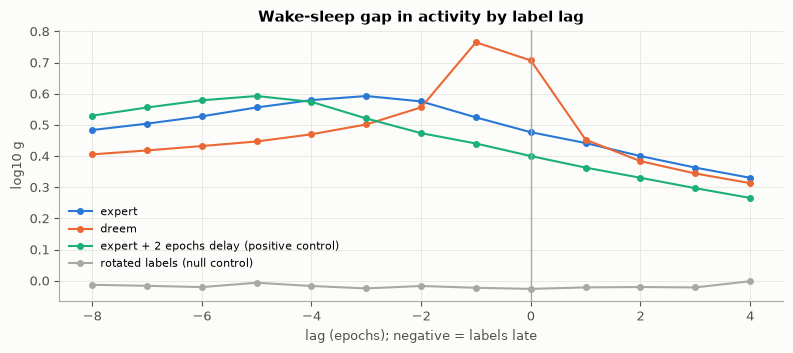

,expert,dreem,expert + 2 epochs delay (positive control),rotated labels (null control)
-8,0.483,0.405,0.529,-0.013
-7,0.504,0.418,0.556,-0.016
-6,0.527,0.432,0.579,-0.021
-5,0.556,0.447,0.593,-0.007
-4,0.579,0.470,0.574,-0.017
-3,0.593,0.501,0.521,-0.025
-2,0.575,0.556,0.473,-0.017
-1,0.524,0.765,0.440,-0.023
0,0.476,0.707,0.400,-0.026
1,0.442,0.452,0.363,-0.021


In [10]:
from sleepwatch.data.label_timing import wake_separation_by_lag

LAGS = list(range(-8, 5))
activity = np.log10(epochs["activity"].clip(lower=1e-5))
nights_data = [
    (g["expert"].to_numpy(), g["dreem"].to_numpy(), activity[g.index].to_numpy())
    for _, g in epochs.groupby(["subject", "night"])
]


def separation_curve(label_index, transform=lambda lab: lab, part=None):
    curve = {}
    for lag in LAGS:
        gaps = []
        for night in nights_data:
            labels, act = transform(night[label_index]), night[2]
            n = len(labels)
            k = np.arange(n)
            if part is not None:
                k = k[(k < n // 2)] if part == "first" else k[(k >= n // 2)]
            k = k[(k + lag >= 0) & (k + lag < n)]
            lab, sig = labels[k], act[k + lag]
            ok = ~np.isnan(sig) & (lab != 5)
            wake, sleep = sig[ok & (lab == 0)], sig[ok & (lab != 0)]
            if len(wake) and len(sleep):
                gaps.append(wake.mean() - sleep.mean())
        curve[lag] = np.mean(gaps)
    return pd.Series(curve)


def delay(extra):
    return lambda lab: np.concatenate([np.full(extra, 5), lab[:-extra]])


rotation = np.random.default_rng(3)
expert_curve = separation_curve(0)
dreem_curve = separation_curve(1)
delayed_curve = separation_curve(0, delay(2))
null_curve = separation_curve(0, lambda lab: np.roll(lab, rotation.integers(60, 200)))
first_half = separation_curve(0, part="first")
second_half = separation_curve(0, part="second")
peak = expert_curve.idxmax()

module = (
    wake_separation_by_lag(epochs.assign(la=activity), "expert", "la", range(-8, 5))
    .groupby("lag")["separation"]
    .mean()
)
check(
    "label timing",
    "independent curve equals the label_timing module's curve",
    np.allclose(module.reindex(LAGS).to_numpy(), expert_curve.to_numpy(), atol=1e-9),
)
check(
    "label timing",
    "expert labels: separation peaks at lag -3",
    peak == -3,
    f"peak {peak}, gap {expert_curve.max():.3f}",
)
check(
    "label timing",
    "Dreem labels: separation peaks within one epoch (lag -1 or 0)",
    dreem_curve.idxmax() in (-1, 0),
    f"peak {dreem_curve.idxmax()}",
)
check(
    "label timing",
    "positive control: 2 extra epochs of delay moves the peak by -2",
    delayed_curve.idxmax() == peak - 2,
    f"peak {delayed_curve.idxmax()}",
)
check(
    "label timing",
    "null control: rotated labels give |gap| < 0.1 at every lag",
    null_curve.abs().max() < 0.1,
    f"max |gap| {null_curve.abs().max():.3f}",
)
check(
    "label timing",
    "same peak in the first and second half of the night (no drift)",
    first_half.idxmax() == second_half.idxmax() == peak,
    f"first {first_half.idxmax()}, second {second_half.idxmax()}",
)

fig, ax = plt.subplots(figsize=(8, 3.6))
series = [
    ("expert", expert_curve, "#2a78d6"),
    ("dreem", dreem_curve, "#eb6834"),
    ("expert + 2 epochs delay (positive control)", delayed_curve, "#1baf7a"),
    ("rotated labels (null control)", null_curve, "#a9a8a3"),
]
for name, curve, color in series:
    ax.plot(curve.index, curve.to_numpy(), color=color, marker="o", ms=4, label=name)
ax.axvline(0, color="#a9a8a3", lw=1)
ax.set(
    title="Wake-sleep gap in activity by label lag",
    xlabel="lag (epochs); negative = labels late",
    ylabel="log10 g",
)
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 0.08), fontsize=8)
plt.tight_layout()
plt.show()
display(pd.DataFrame({name: curve for name, curve, _ in series}).round(3))

## 9 · Dreem vs expert agreement *(independent)*

Recomputed with scikit-learn directly from `labels.mat`, without the epoch table. Only epochs
where neither label is Unknown count, and both sequences start at `recStart`. Values must match
`docs/data.md` to the precision it states.

In [11]:
to4 = np.array([0, 1, 1, 2, 3, 5])
exp_all, dre_all, per_night = [], [], {}
for subject, night in NIGHTS:
    mat = sio.loadmat(RAW / subject / str(night) / "labels.mat")
    e = mat["expert_label"].ravel().astype(int)
    d = mat["dreem_label"].ravel().astype(int)
    n = min(len(e), len(d))
    e, d = e[:n], d[:n]
    ok = (e != 5) & (d != 5)
    exp_all.append(e[ok])
    dre_all.append(d[ok])
    per_night[(subject, night)] = cohen_kappa_score(e[ok], d[ok])
e, d = np.concatenate(exp_all), np.concatenate(dre_all)
k5, k4 = cohen_kappa_score(e, d), cohen_kappa_score(to4[e], to4[d])
per_night = pd.Series(per_night)
low = per_night[per_night < 0.5].round(3)
print("nights with kappa < 0.5:", low.to_dict())
check(
    "agreement",
    "pooled kappa: 0.75 (5-class), 0.82 (4-class)",
    round(k5, 2) == 0.75 and round(k4, 2) == 0.82,
    f"{k5:.3f} / {k4:.3f}",
)
check(
    "agreement",
    "per-night median kappa 0.75",
    round(per_night.median(), 2) == 0.75,
    f"{per_night.median():.3f}",
)
check(
    "agreement",
    "only Bidslab01/4 and Bidslab47/2 are below 0.5",
    set(low.index) == {("Bidslab01", 4), ("Bidslab47", 2)},
)

nights with kappa < 0.5: {('Bidslab01', 4): -0.027, ('Bidslab47', 2): 0.471}
[PASS] pooled kappa: 0.75 (5-class), 0.82 (4-class)  (0.752 / 0.818)
[PASS] per-night median kappa 0.75  (0.750)
[PASS] only Bidslab01/4 and Bidslab47/2 are below 0.5


## 10 · Numbers stated in `docs/data.md` and notebook `01_eda`

Each documented number is recomputed from the quality table and the epoch table. Values are
compared at the precision they are written in the docs.

In [12]:
q = quality.set_index(["subject", "night"])
lab = epochs[epochs["expert"] != 5]
shares = epochs["expert"].value_counts(normalize=True).sort_index()
subject_hr = lab.groupby("subject")["hr_mean"].median()
claims = [
    ("labelled epochs", 218277, len(epochs)),
    ("Unknown expert epochs", 2363, int((epochs["expert"] == 5).sum())),
    ("nights with Unknown epochs", 62, int((q["n_unknown"] > 0).sum())),
    ("% epochs without HR", 2.7, round(100 * (epochs["qc_hr_coverage"] == 0).mean(), 1)),
    ("% epochs without motion", 5.0, round(100 * (epochs["qc_motion_coverage"] == 0).mean(), 1)),
    (
        "nights < 90% coverage on a signal",
        44,
        int(((q["hr_coverage"] < 0.9) | (q["motion_coverage"] < 0.9)).sum()),
    ),
    ("nights with motion < 1/3", 7, int((q["motion_coverage"] < 1 / 3).sum())),
    ("nights ending 58-66 min early", 12, int(q["hr_end_offset_min"].between(-66, -58).sum())),
    (
        "nights with HR every 5 s (in window)",
        252,
        int((q["hr_window_median_dt_s"].round(1) == 5.0).sum()),
    ),
    (
        "the 2 s night",
        "Bidslab06/2",
        "/".join(map(str, q.index[q["hr_window_median_dt_s"].round(1) == 2.0][0])),
    ),
    ("nights with a typical HR step >= 3 bpm", 1, int((q["hr_window_median_step_bpm"] >= 3).sum())),
    (
        "largest typical HR step on other nights (bpm)",
        1,
        int(q["hr_window_median_step_bpm"].drop(("Bidslab06", 2)).max()),
    ),
    ("nights with duplicate HR timestamps", 11, int((q["hr_duplicate_ts"] > 0).sum())),
    ("earliest signal start vs recStart (min)", -38.9, round(q["hr_start_offset_min"].min(), 1)),
    ("latest signal start vs recStart (min)", 122.1, round(q["hr_start_offset_min"].max(), 1)),
    ("subject median HR, lowest (bpm)", 52, round(subject_hr.min())),
    ("subject median HR, highest (bpm)", 82, round(subject_hr.max())),
    ("Wake share (%)", 11, round(100 * shares[0])),
    ("N2 share (%)", 37, round(100 * shares[2])),
    ("REM share (%)", 26, round(100 * shares[4])),
    ("nights flagged out of date order", 0, int((~q["chronological"]).sum())),
]
claims = pd.DataFrame(claims, columns=["claim", "documented", "recomputed"])
claims["ok"] = claims["documented"] == claims["recomputed"]
display(claims)
check(
    "documented numbers",
    "every documented number matches its recomputation",
    claims["ok"].all(),
    f"{claims['ok'].sum()}/{len(claims)} match",
)

,claim,documented,recomputed,ok
0,labelled epochs,218277,218277,True
1,Unknown expert epochs,2363,2363,True
2,nights with Unknown epochs,62,62,True
3,% epochs without HR,2.7,2.7,True
4,% epochs without motion,5.0,5.0,True
5,nights < 90% coverage on a signal,44,44,True
6,nights with motion < 1/3,7,7,True
7,nights ending 58-66 min early,12,12,True
8,nights with HR every 5 s (in window),252,252,True
9,the 2 s night,Bidslab06/2,Bidslab06/2,True


[PASS] every documented number matches its recomputation  (21/21 match)


## 11 · Phase 2: runs and provenance

The latest complete run of each staging experiment is reviewed. Each must come from a clean
commit, the model code (`src/`, `configs/`) must be unchanged since, and every run must use the
same fixed fold file.

In [13]:
import json

from sleepwatch.models.splits import SPLITS_FILE, load_folds

RESULTS = settings.results_dir
index = pd.read_csv(RESULTS / "index.csv")
latest = index[~index["partial"]].groupby("name").tail(1).set_index("name")
expected_runs = {"hgb_main", "gru_main", "hgb_shifted", "gru_shifted", "hgb_dreem_labels"}
check(
    "phase 2",
    "a complete run exists for every staging experiment",
    expected_runs <= set(latest.index),
    ", ".join(sorted(latest.index)),
)
runs = {}
for name, row in latest.iterrows():
    run_dir = RESULTS / name / row["run"]
    runs[name] = {
        "dir": run_dir,
        "run": json.loads((run_dir / "run.json").read_text()),
        "metrics": json.loads((run_dir / "metrics.json").read_text()),
        "pred": pd.read_parquet(run_dir / "predictions.parquet"),
    }
for name, r in runs.items():
    commit = r["run"]["git"]["commit"]
    changed = git(
        "diff", "--name-only", commit, "HEAD", "--", "src", "configs/staging", "configs/splits"
    )
    check(
        "phase 2",
        f"{name}: clean commit and model code unchanged since",
        r["run"]["git"]["dirty"] is False and changed == "",
        f"{commit[:8]}; " + (changed.replace("\n", ", ") or "no changes"),
    )

folds = load_folds()
check(
    "phase 2",
    "fold file assigns all 47 subjects to exactly one of 5 folds",
    len(folds) == 47 and set(folds.values()) == set(range(5)),
)
used = {r["run"].get("splits_file") for r in runs.values()}
check(
    "phase 2",
    "every run used the fixed fold file",
    used == {str(SPLITS_FILE)},
    ", ".join(map(str, used)),
)
changed = git("log", "--oneline", "--", "configs/splits")
check(
    "phase 2",
    "the fold file was committed once and never changed",
    len(changed.splitlines()) == 1,
    changed.replace("\n", "; "),
)

[PASS] a complete run exists for every staging experiment  (gru_main, gru_shifted, hgb_dreem_labels, hgb_main, hgb_shifted)


[PASS] gru_main: clean commit and model code unchanged since  (2f3d637a; no changes)
[PASS] gru_shifted: clean commit and model code unchanged since  (2f3d637a; no changes)
[PASS] hgb_main: clean commit and model code unchanged since  (2f3d637a; no changes)


[PASS] hgb_shifted: clean commit and model code unchanged since  (2f3d637a; no changes)
[PASS] hgb_dreem_labels: clean commit and model code unchanged since  (2f3d637a; no changes)
[PASS] fold file assigns all 47 subjects to exactly one of 5 folds
[PASS] every run used the fixed fold file  (/Users/enricotazzer/Projects/sleepwatch/configs/splits/subject_folds.json)
[PASS] the fold file was committed once and never changed  (bdc65fc Add Phase 2 staging code: splits, metrics, models, experiment runner)


## 12 · Phase 2: folds and completeness

For every run and fold: training and test subjects never overlap, validation subjects are
training subjects, and the test subjects are exactly the fold file's. Every labelled epoch of
every subject is predicted exactly once by the population model, and each personalization
variant scores exactly the fixed evaluation nights.

In [14]:
labelled = epochs[epochs["expert"] != 5]
eval_subjects = quality.groupby("subject")["night"].count().loc[lambda n: n >= 4].index
for name, r in runs.items():
    ok = True
    for entry in r["run"]["folds"]:
        fold_subjects = sorted(s for s, f in folds.items() if f == entry["fold"])
        ok &= not set(entry["train"]) & set(entry["test"])
        ok &= set(entry["val"]) <= set(entry["train"])
        ok &= entry["test"] == fold_subjects
    check("phase 2", f"{name}: folds honoured, train/test disjoint, validation inside train", ok)
    pred = r["pred"]
    population = pred[pred["method"] == "population"]
    keys = ["subject", "night", "epoch"]
    if name.endswith("shifted"):
        # Shifted labels drop the last few epochs of each night (they have no partner label).
        complete = len(population) <= len(labelled) and not population.duplicated(keys).any()
    else:
        complete = len(population) == len(labelled) and not population.duplicated(keys).any()
    check(
        "phase 2",
        f"{name}: every labelled epoch predicted exactly once",
        complete,
        f"{len(population)} of {len(labelled)}",
    )
    proba = pred[[f"proba_{k}" for k in range(5)]].to_numpy()
    check(
        "phase 2",
        f"{name}: probabilities are valid (in [0, 1], rows sum to 1)",
        (proba >= 0).all() and (proba <= 1).all() and np.allclose(proba.sum(axis=1), 1),
    )
    personalized = pred[pred["method"] != "population"]
    if len(personalized):
        n_eval = len(population[population["eval_night"]])
        sizes = personalized.groupby(["method", "n_prior"]).size()
        check(
            "phase 2",
            f"{name}: each personalization variant scores exactly the evaluation nights",
            (sizes == n_eval).all()
            and personalized["eval_night"].all()
            and set(personalized["subject"]) <= set(eval_subjects),
            f"{len(sizes)} variants x {n_eval} epochs",
        )

[PASS] gru_main: folds honoured, train/test disjoint, validation inside train
[PASS] gru_main: every labelled epoch predicted exactly once  (215914 of 215914)
[PASS] gru_main: probabilities are valid (in [0, 1], rows sum to 1)


[PASS] gru_main: each personalization variant scores exactly the evaluation nights  (9 variants x 94173 epochs)
[PASS] gru_shifted: folds honoured, train/test disjoint, validation inside train
[PASS] gru_shifted: every labelled epoch predicted exactly once  (215159 of 215914)
[PASS] gru_shifted: probabilities are valid (in [0, 1], rows sum to 1)
[PASS] hgb_main: folds honoured, train/test disjoint, validation inside train
[PASS] hgb_main: every labelled epoch predicted exactly once  (215914 of 215914)
[PASS] hgb_main: probabilities are valid (in [0, 1], rows sum to 1)


[PASS] hgb_main: each personalization variant scores exactly the evaluation nights  (9 variants x 94173 epochs)
[PASS] hgb_shifted: folds honoured, train/test disjoint, validation inside train
[PASS] hgb_shifted: every labelled epoch predicted exactly once  (215159 of 215914)
[PASS] hgb_shifted: probabilities are valid (in [0, 1], rows sum to 1)
[PASS] hgb_dreem_labels: folds honoured, train/test disjoint, validation inside train
[PASS] hgb_dreem_labels: every labelled epoch predicted exactly once  (215914 of 215914)
[PASS] hgb_dreem_labels: probabilities are valid (in [0, 1], rows sum to 1)


## 13 · Phase 2: headline metrics recomputed *(independent)*

The pooled population scores in each `metrics.json` are recomputed from the saved predictions
with scikit-learn (not the project's metric code). Macro-F1 averages over the stages present in
the true labels; 4-class merges N1 and N2 by summing their probabilities.

In [15]:
from sklearn.metrics import accuracy_score, f1_score

for name, r in runs.items():
    pop = r["pred"][r["pred"]["method"] == "population"]
    proba = pop[[f"proba_{k}" for k in range(5)]].to_numpy()
    y = pop["y_true"].to_numpy()
    for scheme in ["5", "4"]:
        if scheme == "4":
            yy = np.array([0, 1, 1, 2, 3])[y]
            pp = np.column_stack([proba[:, 0], proba[:, 1] + proba[:, 2], proba[:, 3], proba[:, 4]])
        else:
            yy, pp = y, proba
        y_hat = pp.argmax(axis=1)
        stored = r["metrics"]["population"]["all"][scheme]["pooled"]
        mine = {
            "kappa": cohen_kappa_score(yy, y_hat),
            "accuracy": accuracy_score(yy, y_hat),
            "macro_f1": f1_score(yy, y_hat, labels=np.unique(yy), average="macro"),
        }
        check(
            "phase 2",
            f"{name} {scheme}-class: kappa, accuracy and macro-F1 match sklearn",
            all(abs(mine[m] - stored[m]) < 1e-9 for m in mine),
            f"kappa {mine['kappa']:.3f}",
        )

[PASS] gru_main 5-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.510)
[PASS] gru_main 4-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.533)
[PASS] gru_shifted 5-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.509)
[PASS] gru_shifted 4-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.534)
[PASS] hgb_main 5-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.381)
[PASS] hgb_main 4-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.390)
[PASS] hgb_shifted 5-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.384)
[PASS] hgb_shifted 4-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.402)


[PASS] hgb_dreem_labels 5-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.379)
[PASS] hgb_dreem_labels 4-class: kappa, accuracy and macro-F1 match sklearn  (kappa 0.394)


## 14 · Phase 2: personalization and label-shift checks on real data *(pipeline)*

- Personal features for a night must not change when a *later* night of the same person, or
  any other person, is altered (both kinds); `prior_norm` must not change when labels are
  shuffled.
- The shifted runs must have estimated the lag on training subjects, and the estimates should
  agree with the Phase 1 finding (−3).
- The watch-start delays quoted in `docs/data.md` for the two nights whose labels are offset
  (`Bidslab42/1`, `Bidslab68/2`), and the list of nights where the watch starts over 20 min late.
  The lag scan behind the offset finding is in notebook `02_staging`, section 5.

In [16]:
from sleepwatch.models.data import personal_features, prepare

prepared = prepare(epochs)
target = (prepared["subject"] == "Bidslab00") & (prepared["night"] == 5)
for kind in ["prior_norm", "prior_stage"]:
    before = personal_features(prepared, 3, kind)
    altered = prepared.copy()
    later = (altered["subject"] == "Bidslab00") & (altered["night"] == 6)
    altered.loc[later, ["hr_mean", "activity"]] *= 2
    altered.loc[later, "expert"] = 0
    altered.loc[altered["subject"] != "Bidslab00", ["hr_mean", "activity"]] *= 2
    after = personal_features(altered, 3, kind)
    check(
        "phase 2",
        f"{kind}: night 5 unaffected by night 6 or other subjects",
        before[target].equals(after[target]),
    )
shuffled = prepared.assign(
    expert=np.random.default_rng(0).permutation(prepared["expert"].to_numpy())
)
check(
    "phase 2",
    "prior_norm ignores labels",
    personal_features(prepared, 3, "prior_norm").equals(
        personal_features(shuffled, 3, "prior_norm")
    ),
)
for name in ["hgb_shifted", "gru_shifted"]:
    if name in runs:
        lags = [entry["label_lag"] for entry in runs[name]["run"]["folds"]]
        check(
            "phase 2",
            f"{name}: lag estimated per fold on training subjects agrees with -3",
            all(lag == -3 for lag in lags),
            f"lags {lags}",
        )
start = quality.set_index(["subject", "night"])["hr_start_offset_min"]
check(
    "documented numbers",
    "watch starts 30.7 and 59.2 min late on Bidslab42/1 and Bidslab68/2",
    [round(start[("Bidslab42", 1)], 1), round(start[("Bidslab68", 2)], 1)] == [30.7, 59.2],
    f"{start[('Bidslab42', 1)]:.2f}, {start[('Bidslab68', 2)]:.2f} min",
)
late = sorted(f"{s}/{n}" for s, n in start[start > 20].index)
check(
    "documented numbers",
    "watch starts > 20 min late on exactly 5 nights, 14/4 at 122 min",
    late == ["Bidslab02/2", "Bidslab02/4", "Bidslab14/4", "Bidslab42/1", "Bidslab68/2"]
    and round(start[("Bidslab14", 4)]) == 122,
    ", ".join(late),
)

[PASS] prior_norm: night 5 unaffected by night 6 or other subjects


[PASS] prior_stage: night 5 unaffected by night 6 or other subjects


[PASS] prior_norm ignores labels
[PASS] hgb_shifted: lag estimated per fold on training subjects agrees with -3  (lags [-3, -3, -3, -3, -3])
[PASS] gru_shifted: lag estimated per fold on training subjects agrees with -3  (lags [-3, -3, -3, -3, -3])
[PASS] watch starts 30.7 and 59.2 min late on Bidslab42/1 and Bidslab68/2  (30.72, 59.19 min)
[PASS] watch starts > 20 min late on exactly 5 nights, 14/4 at 122 min  (Bidslab02/2, Bidslab02/4, Bidslab14/4, Bidslab42/1, Bidslab68/2)


## 15 · Phase 2: reproducibility *(pipeline, ~6 minutes)*

Fold 0 of each population model is retrained from scratch with its saved config (tuning and
early stopping included) and must reproduce the saved predictions exactly. The saved GRU run
trained its folds in 5 parallel processes; the retrain here runs serially, so this also checks
that `--jobs` doesn't change results on real data.

In [17]:
import yaml

from sleepwatch.models.experiment import StagingConfig, run_folds

RUN_REPRODUCIBILITY = True
if RUN_REPRODUCIBILITY:
    cols_p = [f"proba_{k}" for k in range(5)]
    for name in ["hgb_main", "gru_main"]:
        saved = yaml.safe_load((runs[name]["dir"] / "config.yaml").read_text())
        cfg_repro = StagingConfig.model_validate({**saved, "personalization": [], "folds": [0]})
        again, _ = run_folds(cfg_repro, epochs, folds, log=lambda *_: None)
        stored = runs[name]["pred"]
        stored = stored[(stored["method"] == "population") & (stored["fold"] == 0)]
        same_rows = len(again) == len(stored) and np.array_equal(
            again[["subject", "night", "epoch"]].to_numpy(),
            stored[["subject", "night", "epoch"]].to_numpy(),
        )
        gap = np.inf
        if same_rows:
            gap = np.abs(again[cols_p].to_numpy() - stored[cols_p].to_numpy()).max()
        check(
            "phase 2",
            f"{name} fold 0 retrained from scratch reproduces saved predictions",
            same_rows and gap <= 1e-12,
            f"largest probability difference {gap:.1e}",
        )

[PASS] hgb_main fold 0 retrained from scratch reproduces saved predictions  (largest probability difference 0.0e+00)


[PASS] gru_main fold 0 retrained from scratch reproduces saved predictions  (largest probability difference 0.0e+00)


## 16 · Test suite

Runs the project's unit tests (including the real-data tests).

In [18]:
import os

run = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    env={**os.environ, "PY_COLORS": "0"},
)
summary = run.stdout.strip().splitlines()[-1]
print(summary)
check("tests", "all unit tests pass", run.returncode == 0 and "failed" not in summary, summary)

81 passed in 30.74s
[PASS] all unit tests pass  (81 passed in 30.74s)


## Summary

In [19]:
summary = pd.DataFrame(results)
failed = summary[summary["result"] == "FAIL"]
print(
    f"{(summary['result'] == 'PASS').sum()} of {len(summary)} checks passed; "
    f"{len(failed)} failed, {(failed['note'] != '').sum()} of them with a diagnosis"
)
pd.set_option("display.max_colwidth", 200)
display(summary)

87 of 88 checks passed; 1 failed, 1 of them with a diagnosis


,section,claim,result,detail,note
0,provenance,table built from a clean working tree,PASS,,
1,provenance,table-building code unchanged since the build,PASS,"data/, features/, constants, config, configs/features",
2,provenance,everything else in src/ and configs/ changed only by additions since the build,PASS,13 files with added lines only (Phase 2),
3,provenance,table covers all 253 nights / 47 subjects,PASS,"253/253 nights, 47 subjects",
4,integrity,"checksum list has 761 files: 3 per night for 253 nights, 47 subjects",PASS,,
...,...,...,...,...,...
83,documented numbers,watch starts 30.7 and 59.2 min late on Bidslab42/1 and Bidslab68/2,PASS,"30.72, 59.19 min",
84,documented numbers,"watch starts > 20 min late on exactly 5 nights, 14/4 at 122 min",PASS,"Bidslab02/2, Bidslab02/4, Bidslab14/4, Bidslab42/1, Bidslab68/2",
85,phase 2,hgb_main fold 0 retrained from scratch reproduces saved predictions,PASS,largest probability difference 0.0e+00,
86,phase 2,gru_main fold 0 retrained from scratch reproduces saved predictions,PASS,largest probability difference 0.0e+00,


## What this notebook cannot check: read these by hand

The checks above confirm the code does what the documentation says. They cannot confirm the
documentation describes the *right* thing. Questions worth a human look:

1. **Is the label-timing interpretation right?** Section 8 shows a robust, constant offset, but
   *why* the expert labels are late is unknown. It could be an export shift in the expert's
   scoring tool, a genuinely different alignment intended by the authors, or a physiological
   effect the checks don't separate out. Phase 2 reports both alignments for this reason.
2. **Alignment code.** [`loader.py`](../src/sleepwatch/data/loader.py) `load_night` and
   `rec_start_to_unix`, and [`align.py`](../src/sleepwatch/data/align.py) `resample` (gaps are
   never bridged).
3. **Feature definitions.** [`epoch_features.py`](../src/sleepwatch/features/epoch_features.py):
   are these sensible features for sleep staging? Is anything missing?
4. **The sign convention for lags.** [`label_timing.py`](../src/sleepwatch/data/label_timing.py)
   and its synthetic test [`test_label_timing.py`](../tests/test_label_timing.py): the positive
   control in section 8 checks this on real data too.
5. **Decisions.** [`docs/decisions.md`](../docs/decisions.md) should match what you actually
   decided.
6. **Two nights with offset labels.** `02_staging` section 5 argues that the labels of
   `Bidslab42/1` and `Bidslab68/2` start when the watch starts, not at `recStart`. They are kept
   uncorrected. Is the evidence convincing, and should they be corrected or excluded in later
   phases?
7. **Personal features.** [`data.py`](../src/sleepwatch/models/data.py) `personal_features`: is
   this a fair test of personalization? Section 14 checks that it doesn't leak, not that it's a
   good design.
8. **The GRU.** [`gru.py`](../src/sleepwatch/models/gru.py) `Net` runs each direction as a
   separate GRU over the night, with the backward one reading the night reversed within its
   length. [`test_gru.py`](../tests/test_gru.py) checks it against PyTorch's packed
   bidirectional GRU.